# 04 — EDA & Visualization Optimized

Notebook tối ưu cho **Giai đoạn 4 — Phân tích khám phá dữ liệu và trực quan hóa dữ liệu tuyển dụng**.

Đề tài: **Phân cụm tin tuyển dụng tại Việt Nam dựa trên mô tả công việc, yêu cầu ứng viên và đặc điểm tuyển dụng**

## Các tối ưu so với bản trước

- Dùng `location_city` thay vì `location` gốc.
- Dùng `primary_industry` thay vì chỉ dùng `job_industry`.
- Tạo `job_position_display` để gom nhãn trùng do khác viết hoa.
- Tạo `education_level_display` để biểu đồ dễ giải thích hơn.
- Salary valid lọc chặt hơn: VND, no issue, 1–200 triệu/tháng.
- Thêm biểu đồ salary zoom 1–50 triệu.
- Bỏ `Khác/Không rõ` khỏi boxplot salary theo tỉnh/thành.
- Thêm biểu đồ top ngành có lương trung vị cao nhất.
- Lọc một số n-grams bị gãy hoặc quá chung chung.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 180)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 11

## 1. Cấu hình đường dẫn

In [2]:
PROJECT_ROOT = Path("..").resolve()

if not (PROJECT_ROOT / "data" / "clean" / "clean_data_train.csv").exists():
    PROJECT_ROOT = Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "data"
CLEAN_DIR = DATA_DIR / "clean"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
EDA_DIR = OUTPUT_DIR / "eda_stage_04"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
EDA_DIR.mkdir(parents=True, exist_ok=True)

clean_train_path = CLEAN_DIR / "clean_data_train.csv"
clean_test_path = CLEAN_DIR / "clean_data_test.csv"

print("Project root:", PROJECT_ROOT)
print("Clean train:", clean_train_path)
print("Clean test:", clean_test_path)

Project root: D:\DataScientFinalProject
Clean train: D:\DataScientFinalProject\data\clean\clean_data_train.csv
Clean test: D:\DataScientFinalProject\data\clean\clean_data_test.csv


## 2. Load clean data

In [3]:
clean_train = pd.read_csv(clean_train_path)
clean_test = pd.read_csv(clean_test_path)

print("Clean train shape:", clean_train.shape)
print("Clean test shape:", clean_test.shape)

display(clean_train.head())

Clean train shape: (546190, 31)
Clean test shape: (60688, 31)


,id,job_title,company_name,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,requirements,year,location_city,location_city_is_unknown,primary_industry,salary_available,salary_min_million_vnd,salary_max_million_vnd,salary_avg_million_vnd,salary_currency,salary_parse_issue,job_title_char_len,job_title_word_count,job_description_char_len,job_description_word_count,requirements_char_len,requirements_word_count,benefits_char_len,benefits_word_count
0,301834,nhân viên kinh doanh - thu nhập đến 30 triệu (đi làm ngay),Công Ty TNHH Bê Tông Trang Trí Việt Nam,12.000.000 - 30.000.000 VND,"Tầng 5, Tòa nhà Phú Hưng 298 Ung Văn Khiêm | 56 Hàng Chuối, Phạm Đình Hổ, Hai Bà Trưng, Hà Nội",Toàn thời gian,Xây dựng,6 năm,Cao đẳng,Nhân viên,"lên kế hoạch tiếp cận, chăm sóc khách hàng là chủ đầu tư, nhà thầu xây dựng, văn phòng kiến trúc sư. - xây dựng và mở rộng các mối quan hệ với các đối tác, chủ đầu tư, chủ dự á...","thu nhập: từ 12- 30 triệu ( lương cứng + hoa hồng bán hàng, dự án) - môi trường làm việc năng động, thúc đẩy phát triển nghề nghiệp, khả năng thăng tiến cao. - các chế độ bhxh ...","độ tuổi từ 27-40, tốt nghiệp cao đẳng, đại học các ngành kinh tế, quản trị kinh doanh. - có 4 năm kinh nghiệm ở vị trí tương đương - kỹ năng đàm phán, thuyết trình. - kỹ năng g...",2024,Hà Nội,0,Xây dựng,1,12.0,30.0,21.0,VND,0,58,13,480,108,607,136,416,92
1,477331,nv pha chế. caffe,Caffe,6.000.000 - 10.000.000 VND,880 tỉnh lộ 43 phường bình chiểu,Remote,Bán hàng - Kinh doanh,2 năm,Không,Nhân viên,"tìm kiếm khách hàng tiềm năng, mở rộng nguồn khách hàng - tư vấn khách hàng, giới thiệu sản phẩm của công ty đến với khách hàng - thực hiện các thủ tục ký kết hợp đồng với khác...","lương cơ bản + hoa hồng + thưởng kpi - được hưởng đầy đủ chế độ bảo hiểm theo quy định - du lịch, nghỉ mát, teambuilding - chế độ tăng lương hàng năm - môi trường làm việc năng...","nam/nữ từ 22 – 35 tuổi, có đam mê và nhiệt huyết kinh doanh - có tinh thần cầu tiến, năng động, nhiệt huyết với công việc - ứng viên có 2-3 năm kinh nghiệm là ưu thế - siêng nă...",2025,Khác/Không rõ,1,Bán hàng - Kinh doanh,1,6.0,10.0,8.0,VND,0,17,4,610,136,200,45,205,45
2,540064,kỹ sư giám sát xây dựng,Công Ty TNHH XD TM DV Không Gian Đẹp,10.000.000 - 15.000.000 VND,"68 Song Hành, Quốc lộ 22, Trung Chánh | 72/3C Ấp Mỹ Hòa 1, Xã Trung Chánh, Huyện Hóc Môn, Thành phố Hồ Chí Minh, Việt Nam",Toàn thời gian,Xây dựng,5 năm,Đại học,Nhân viên,"• giám sát, quản lý các tổ đội, từ phần thô đến hoàn thiện, ctr nhà phố, biệt thự, vp… • xây dựng kế hoạch triển khai, kế hoạch vật tư xuyên suốt dự án • nghiệm thu nguyên, vật...","• mức lương: 10 - 14tr + phụ cấp công việc • phúc lợi: được hưởng các chế độ thưởng lễ, tết, lương tháng 13…đầy đủ theo quy định nhà nước và công ty. • được thưởng theo công tr...",• tốt nghiệp đại học chuyên ngành xây dựng dân dụng và công nghiệp • trên 26 tuổi • ưu tiên 3 năm kinh nghiệm ở vị trí kỹ sư giám sát • nơi làm việc linh hoạt tuỳ theo công trì...,2025,TP Hồ Chí Minh,0,Xây dựng,1,10.0,15.0,12.5,VND,0,23,6,475,108,343,78,339,74
3,114270,"tuyển sales, telesales cho công ty bhnt prudential",Công Ty TNHH Một Thành Viên Đại Lý Bảo Hiểm Gl,5.000.000 - 7.000.000 VND,"153 Cách Mạng Tháng Tám, Phường Hoa Lư, Thành phố Pleiku, Tỉnh Gia Lai",Toàn thời gian,Chưa xác định,1 năm,Trung học,Chưa cập nhật,"gọi điện thoại, kết nối và lên hẹn với khách hàng, gặp khách hàng chốt hợp đồng, nhanh nhẹn chăm chỉ, được đào tạo khi nhận việc, có kinh nghiệm là 1 lợi thế","được hưởng đầy đủ chế độ bhxh và nghỉ lễ của nhà nhà nước, được cân nhắc tăng lương định kỳ 6 tháng 1 lần, được thưởng tháng, quý và thưởng nếu vượt chỉ tiêu.","cần ứng viên từ 21 tuổi, tốt nghiệp thpt trở lên",2022,Gia Lai,0,Chưa xác định,1,5.0,7.0,6.0,VND,0,50,8,157,34,48,11,158,35
4,322289,kế toán tổng hợp,CÔNG TY TNHH XUẤT NHẬP KHẨU Ô TÔ MIỀN NAM,8.000.000 - 10.000.000 VND,"159 Nguyễn Chí Thanh | 68 QL1A, Phường An Phú Đông, Quận 12, Thành phố Hồ Chí Minh, Việt Nam",Toàn thời g

## 3. Kiểm tra schema và các cột cần thiết

In [4]:
required_columns = [
    "id", "job_title", "company_name", "salary", "location",
    "location_city", "location_city_is_unknown",
    "job_type", "job_industry", "primary_industry",
    "experience_level", "education_level", "job_position",
    "job_description", "benefits", "requirements", "year",
    "salary_available", "salary_min_million_vnd",
    "salary_max_million_vnd", "salary_avg_million_vnd",
    "salary_currency", "salary_parse_issue"
]

missing_required_columns = [col for col in required_columns if col not in clean_train.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}")

schema_df = pd.DataFrame({
    "column": clean_train.columns,
    "dtype": [str(dtype) for dtype in clean_train.dtypes],
    "missing_count": clean_train.isna().sum().values,
    "missing_ratio": clean_train.isna().mean().values
}).sort_values("missing_ratio", ascending=False)

schema_df.to_csv(TABLE_DIR / "stage_04_clean_train_schema.csv", index=False, encoding="utf-8-sig")

print("All required columns are available.")
display(schema_df)

All required columns are available.


,column,dtype,missing_count,missing_ratio
20,salary_avg_million_vnd,float64,45521,0.083343
19,salary_max_million_vnd,float64,45521,0.083343
18,salary_min_million_vnd,float64,45521,0.083343
11,benefits,str,3524,0.006452
12,requirements,str,3361,0.006154
10,job_description,str,25,0.000046
1,job_title,str,18,0.000033
6,job_industry,str,0,0.000000
5,job_type,str,0,0.000000
4,location,str,0,0.000000


## 4. Tạo cột hiển thị tối ưu cho EDA

In [5]:
def normalize_job_position_display(value):
    if pd.isna(value):
        return "Unknown"

    text = str(value).strip()

    mapping = {
        "Nhân Viên": "Nhân viên",
        "Trưởng Nhóm": "Trưởng nhóm",
        "Thực Tập Sinh": "Thực tập sinh",
        "Sinh Viên/ Thực Tập Sinh": "Sinh viên/Thực tập sinh",
        "Quản Lý": "Quản lý",
        "Giám Đốc": "Giám đốc",
    }

    return mapping.get(text, text)


def normalize_education_level_display(value):
    if pd.isna(value):
        return "Unknown"

    text = str(value).strip()

    mapping = {
        "Không": "Không yêu cầu/không ghi rõ",
        "Unknown": "Không yêu cầu/không ghi rõ",
    }

    return mapping.get(text, text)


clean_train["job_position_display"] = clean_train["job_position"].apply(normalize_job_position_display)
clean_test["job_position_display"] = clean_test["job_position"].apply(normalize_job_position_display)

clean_train["education_level_display"] = clean_train["education_level"].apply(normalize_education_level_display)
clean_test["education_level_display"] = clean_test["education_level"].apply(normalize_education_level_display)

display(clean_train[[
    "job_position", "job_position_display",
    "education_level", "education_level_display"
]].head())

,job_position,job_position_display,education_level,education_level_display
0,Nhân viên,Nhân viên,Cao đẳng,Cao đẳng
1,Nhân viên,Nhân viên,Không,Không yêu cầu/không ghi rõ
2,Nhân viên,Nhân viên,Đại học,Đại học
3,Chưa cập nhật,Chưa cập nhật,Trung học,Trung học
4,Nhân viên,Nhân viên,Cao đẳng,Cao đẳng


## 5. Hàm tiện ích

In [6]:
def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("Saved table:", path)


def save_fig(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved figure:", path)


def add_count_ratio(df, count_col="count", total=None):
    result = df.copy()
    if total is None:
        total = result[count_col].sum()
    result["ratio"] = result[count_col] / total
    result["ratio_percent"] = result["ratio"] * 100
    return result


def get_top_counts(df, column, top_n=15):
    result = (
        df[column]
        .value_counts(dropna=False)
        .head(top_n)
        .rename_axis(column)
        .reset_index(name="count")
    )
    return add_count_ratio(result, total=len(df))


def shorten_label(value, max_len=60):
    text = str(value)
    if len(text) <= max_len:
        return text
    return text[:max_len - 3] + "..."


def plot_horizontal_bar(data, label_col, value_col, title, xlabel, ylabel, filename, max_label_len=80):
    plot_data = data.copy()
    plot_data["_label"] = plot_data[label_col].apply(lambda x: shorten_label(x, max_label_len))
    plot_data = plot_data.iloc[::-1]

    plt.figure(figsize=(11, max(5, len(plot_data) * 0.42)))
    plt.barh(plot_data["_label"].astype(str), plot_data[value_col])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    save_fig(filename)
    plt.show()


def plot_hist(series, title, xlabel, ylabel, filename, bins=50, cap_quantile=None):
    plot_series = series.dropna().copy()

    if cap_quantile is not None:
        upper = plot_series.quantile(cap_quantile)
        plot_series = plot_series[plot_series <= upper]

    plt.figure(figsize=(10, 6))
    plt.hist(plot_series, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    save_fig(filename)
    plt.show()


def compare_train_test_distribution(train_df, test_df, column):
    train_ratio = train_df[column].value_counts(normalize=True, dropna=False)
    test_ratio = test_df[column].value_counts(normalize=True, dropna=False)

    compare_df = pd.DataFrame({
        "train_ratio": train_ratio,
        "test_ratio": test_ratio
    }).fillna(0)

    compare_df["abs_diff"] = (compare_df["train_ratio"] - compare_df["test_ratio"]).abs()

    return (
        compare_df
        .sort_values("train_ratio", ascending=False)
        .reset_index()
        .rename(columns={"index": column})
    )

## 6. Tổng quan dữ liệu sạch

In [7]:
n_display_columns_added = 2

overview = {
    "n_train_rows": len(clean_train),
    "n_test_rows": len(clean_test),
    "n_clean_input_columns": clean_train.shape[1] - n_display_columns_added,
    "n_eda_columns_after_display": clean_train.shape[1],
    "n_unique_job_title": clean_train["job_title"].nunique(),
    "n_unique_company_name": clean_train["company_name"].nunique(),
    "n_unique_location_city": clean_train["location_city"].nunique(),
    "n_unique_job_industry": clean_train["job_industry"].nunique(),
    "n_unique_primary_industry": clean_train["primary_industry"].nunique(),
    "location_city_unknown_count": int(clean_train["location_city_is_unknown"].sum()),
    "location_city_unknown_ratio": clean_train["location_city_is_unknown"].mean(),
    "salary_available_ratio": clean_train["salary_available"].mean(),
    "salary_parse_issue_ratio": clean_train["salary_parse_issue"].mean(),
}

overview_df = pd.DataFrame([overview])
save_table(overview_df, "stage_04_overview.csv")
display(overview_df)

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_overview.csv


,n_train_rows,n_test_rows,n_clean_input_columns,n_eda_columns_after_display,n_unique_job_title,n_unique_company_name,n_unique_location_city,n_unique_job_industry,n_unique_primary_industry,location_city_unknown_count,location_city_unknown_ratio,salary_available_ratio,salary_parse_issue_ratio
0,546190,60688,31,33,271093,109743,64,4090,2783,13455,0.024634,0.91697,0.014076


## 7. Phân tích ngành chính

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_top_primary_industries.csv


,primary_industry,count,ratio,ratio_percent
0,Bán hàng - Kinh doanh,52977,0.096994,9.699372
1,Chăm sóc khách hàng,50531,0.092515,9.251543
2,Kế toán / Kiểm toán,45469,0.083248,8.324759
3,Xây dựng,27020,0.049470,4.946996
4,Chưa xác định,23057,0.042214,4.221425
5,Cơ khí - Ô tô - Tự động hóa / Sản xuất - Lắp ráp - Chế biến,22371,0.040958,4.095827
6,Khoa học - Kỹ thuật,21595,0.039538,3.953752
7,Lao động phổ thông,21068,0.038573,3.857266
8,Nghề nghiệp khác,20985,0.038421,3.842070
9,Giáo dục - Đào tạo / Biên phiên dịch,16638,0.030462,3.046193


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_top_primary_industries.png


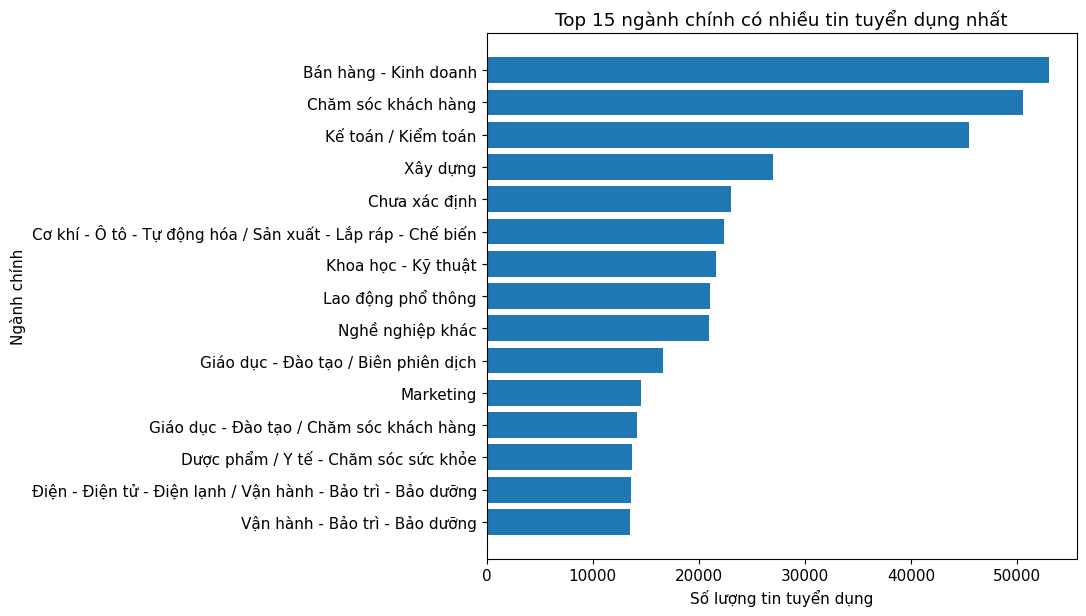

In [8]:
primary_industry_counts = get_top_counts(clean_train, column="primary_industry", top_n=15)

save_table(primary_industry_counts, "stage_04_top_primary_industries.csv")
display(primary_industry_counts)

plot_horizontal_bar(
    data=primary_industry_counts,
    label_col="primary_industry",
    value_col="count",
    title="Top 15 ngành chính có nhiều tin tuyển dụng nhất",
    xlabel="Số lượng tin tuyển dụng",
    ylabel="Ngành chính",
    filename="stage_04_top_primary_industries.png",
    max_label_len=70
)

## 8. Phân tích địa điểm theo tỉnh/thành

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_top_location_cities.csv


,location_city,count,ratio,ratio_percent
0,TP Hồ Chí Minh,285382,0.522496,52.249583
1,Hà Nội,141002,0.258156,25.815559
2,Bình Dương,25368,0.046445,4.644538
3,Khác/Không rõ,13455,0.024634,2.463428
4,Đồng Nai,10150,0.018583,1.858328
5,Đà Nẵng,8277,0.015154,1.515407
6,Long An,7148,0.013087,1.308702
7,Bắc Ninh,4823,0.008830,0.883026
8,Hải Phòng,4542,0.008316,0.831579
9,Hưng Yên,4451,0.008149,0.814918


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_top_location_cities.png


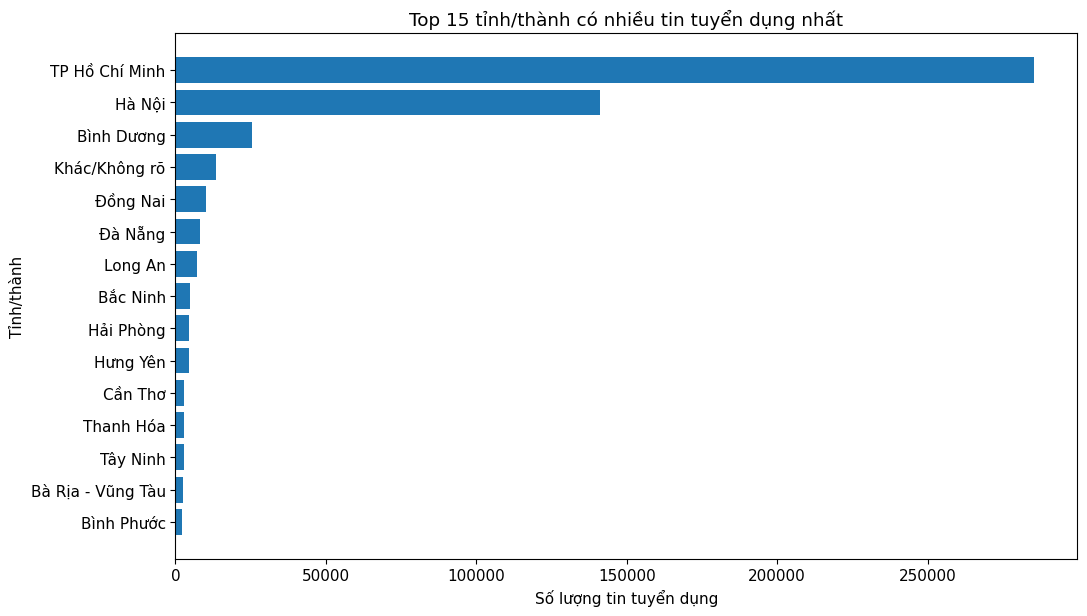

In [9]:
location_city_counts = get_top_counts(clean_train, column="location_city", top_n=15)

save_table(location_city_counts, "stage_04_top_location_cities.csv")
display(location_city_counts)

plot_horizontal_bar(
    data=location_city_counts,
    label_col="location_city",
    value_col="count",
    title="Top 15 tỉnh/thành có nhiều tin tuyển dụng nhất",
    xlabel="Số lượng tin tuyển dụng",
    ylabel="Tỉnh/thành",
    filename="stage_04_top_location_cities.png"
)

## 9. Tỷ lệ nhận diện location_city

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_location_city_unknown_distribution.csv


,location_status,count,ratio,ratio_percent
0,Nhận diện được,532735,0.975366,97.536572
1,Khác/Không rõ,13455,0.024634,2.463428


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_location_city_unknown_distribution.png


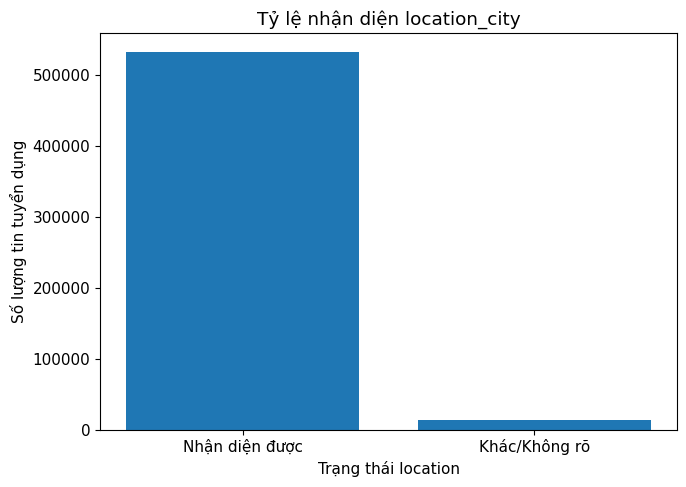

In [10]:
location_unknown_counts = (
    clean_train["location_city_is_unknown"]
    .map({0: "Nhận diện được", 1: "Khác/Không rõ"})
    .value_counts(dropna=False)
    .rename_axis("location_status")
    .reset_index(name="count")
)

location_unknown_counts = add_count_ratio(location_unknown_counts, total=len(clean_train))

save_table(location_unknown_counts, "stage_04_location_city_unknown_distribution.csv")
display(location_unknown_counts)

plt.figure(figsize=(7, 5))
plt.bar(location_unknown_counts["location_status"], location_unknown_counts["count"])
plt.title("Tỷ lệ nhận diện location_city")
plt.xlabel("Trạng thái location")
plt.ylabel("Số lượng tin tuyển dụng")
save_fig("stage_04_location_city_unknown_distribution.png")
plt.show()

## 10. Phân tích hình thức làm việc

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_job_type_distribution.csv


,job_type,count,ratio,ratio_percent
0,Toàn thời gian,503335,0.921538,92.153829
1,Thực tập,15596,0.028554,2.855417
2,Khác,8319,0.015231,1.523096
3,Bán thời gian,6496,0.011893,1.189330
4,Remote,5271,0.009650,0.965049
5,Thời vụ,2901,0.005311,0.531134
6,Chưa xác định,2756,0.005046,0.504586
7,Không,693,0.001269,0.126879
8,Hợp đồng,508,0.000930,0.093008
9,Theo ca,181,0.000331,0.033139


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_job_type_distribution.png


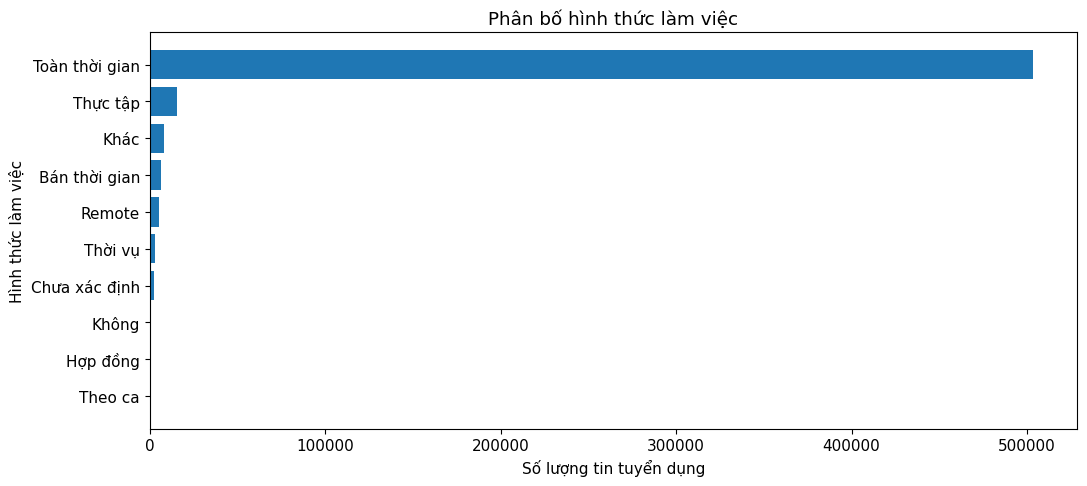

In [11]:
job_type_counts = get_top_counts(clean_train, column="job_type", top_n=10)

save_table(job_type_counts, "stage_04_job_type_distribution.csv")
display(job_type_counts)

plot_horizontal_bar(
    data=job_type_counts,
    label_col="job_type",
    value_col="count",
    title="Phân bố hình thức làm việc",
    xlabel="Số lượng tin tuyển dụng",
    ylabel="Hình thức làm việc",
    filename="stage_04_job_type_distribution.png"
)

## 11. Phân tích kinh nghiệm, học vấn, cấp bậc

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_experience_level_distribution.csv


,experience_level,count,ratio,ratio_percent
0,3 năm,158294,0.289815,28.981490
1,1 năm,145299,0.266023,26.602281
2,2 năm,83977,0.153751,15.375053
3,4 năm,75129,0.137551,13.755104
4,5 năm,35490,0.064977,6.497739
5,Không,17481,0.032005,3.200535
6,7 năm,9255,0.016945,1.694465
7,Dưới 1 năm,6314,0.011560,1.156008
8,8 năm,3384,0.006196,0.619565
9,6 năm,2676,0.004899,0.489939


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_experience_level_distribution.png


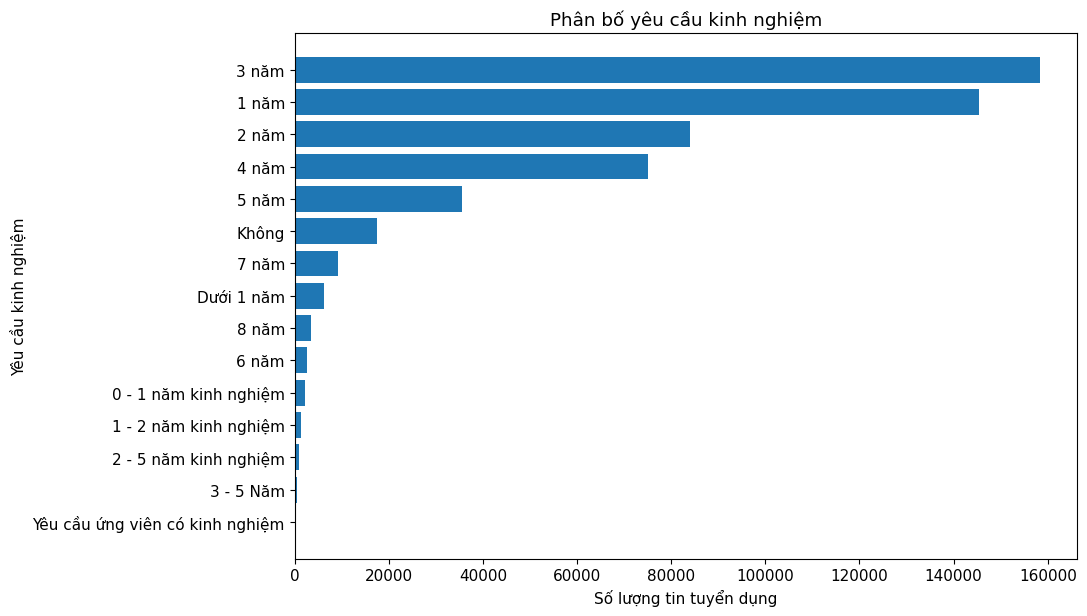

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_education_level_distribution.csv


,education_level_display,count,ratio,ratio_percent
0,Không yêu cầu/không ghi rõ,189065,0.346152,34.615244
1,Cao đẳng,132029,0.241727,24.172724
2,Đại học,86403,0.158192,15.819220
3,Trung cấp,84451,0.154618,15.461836
4,Trung học,44818,0.082056,8.205569
5,Chứng chỉ,8296,0.015189,1.518885
6,Cử nhân,1048,0.001919,0.191875
7,Khác,51,0.000093,0.009337
8,Kỹ sư,27,0.000049,0.004943
9,Bằng cấp liên quan,2,0.000004,0.000366


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_education_level_distribution.png


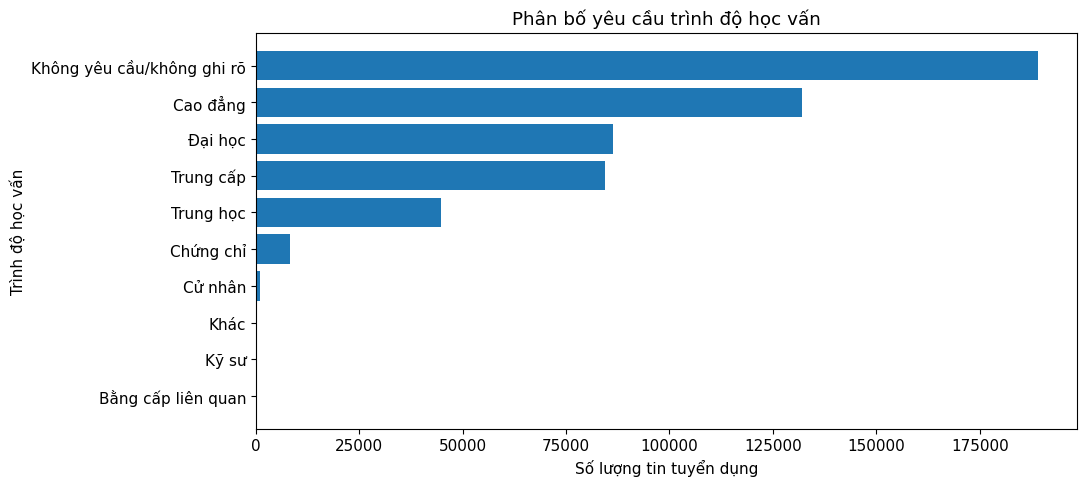

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_job_position_distribution.csv


,job_position_display,count,ratio,ratio_percent
0,Nhân viên,430832,0.788795,78.879511
1,Chưa cập nhật,43147,0.078996,7.899632
2,Trưởng nhóm,26253,0.048066,4.806569
3,Trưởng phòng,17267,0.031614,3.161354
4,Cộng tác viên,12212,0.022359,2.235852
5,Giám đốc,8851,0.016205,1.620498
6,Chuyên gia,3113,0.005699,0.569948
7,Thực tập sinh,790,0.001446,0.144638
8,Quản lý,483,0.000884,0.088431
9,Unknown,404,0.000740,0.073967


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_job_position_distribution.png


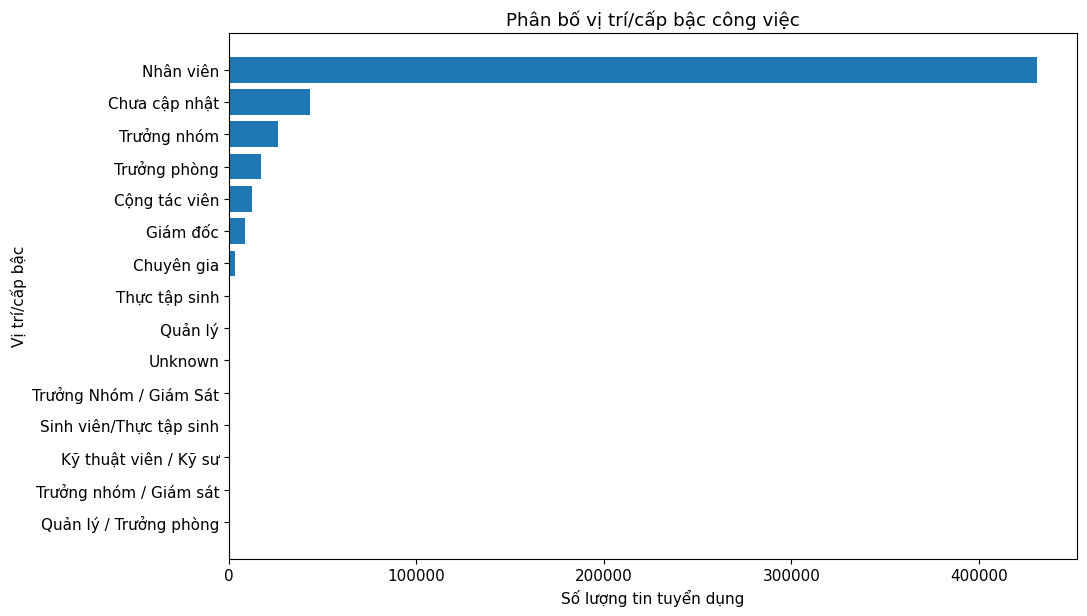

In [12]:
experience_counts = get_top_counts(clean_train, column="experience_level", top_n=15)
save_table(experience_counts, "stage_04_experience_level_distribution.csv")
display(experience_counts)
plot_horizontal_bar(
    data=experience_counts,
    label_col="experience_level",
    value_col="count",
    title="Phân bố yêu cầu kinh nghiệm",
    xlabel="Số lượng tin tuyển dụng",
    ylabel="Yêu cầu kinh nghiệm",
    filename="stage_04_experience_level_distribution.png"
)

education_counts = get_top_counts(clean_train, column="education_level_display", top_n=15)
save_table(education_counts, "stage_04_education_level_distribution.csv")
display(education_counts)
plot_horizontal_bar(
    data=education_counts,
    label_col="education_level_display",
    value_col="count",
    title="Phân bố yêu cầu trình độ học vấn",
    xlabel="Số lượng tin tuyển dụng",
    ylabel="Trình độ học vấn",
    filename="stage_04_education_level_distribution.png",
    max_label_len=50
)

position_counts = get_top_counts(clean_train, column="job_position_display", top_n=15)
save_table(position_counts, "stage_04_job_position_distribution.csv")
display(position_counts)
plot_horizontal_bar(
    data=position_counts,
    label_col="job_position_display",
    value_col="count",
    title="Phân bố vị trí/cấp bậc công việc",
    xlabel="Số lượng tin tuyển dụng",
    ylabel="Vị trí/cấp bậc",
    filename="stage_04_job_position_distribution.png",
    max_label_len=50
)

## 12. Phân tích salary hợp lệ

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_salary_valid_describe.csv
Valid salary rows: 492340
Valid salary ratio: 0.9014079349676852


,column,count,mean,std,min,25%,50%,75%,max
0,salary_min_million_vnd,492340.0,9.943125,4.987570,1.0,7.0,9.0,12.0,200.0
1,salary_max_million_vnd,492340.0,17.111395,11.478154,1.0,10.0,15.0,20.0,200.0
2,salary_avg_million_vnd,492340.0,13.527260,7.528084,1.0,9.0,12.0,15.5,200.0


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_salary_avg_distribution.png


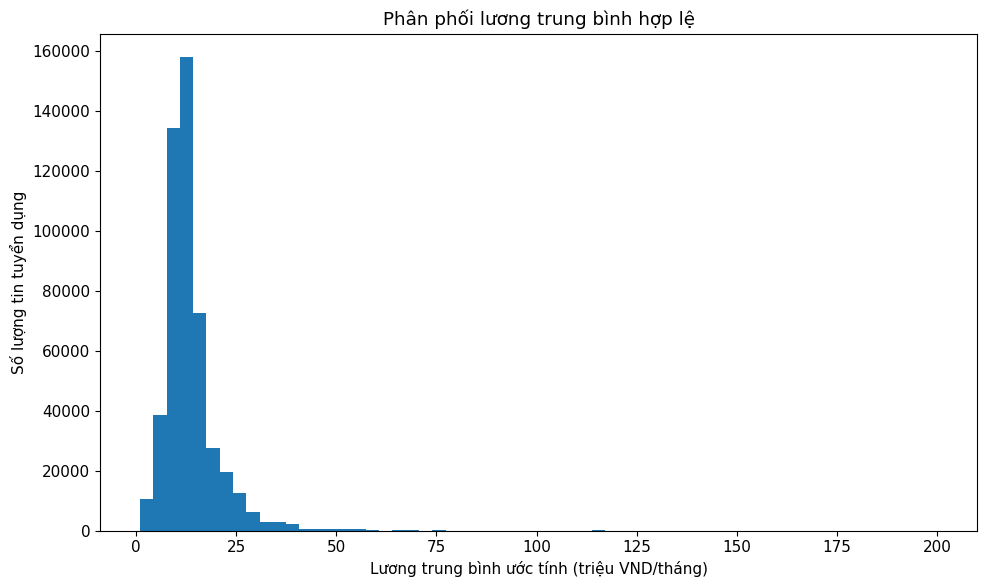

Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_salary_avg_distribution_zoom_1_50.png


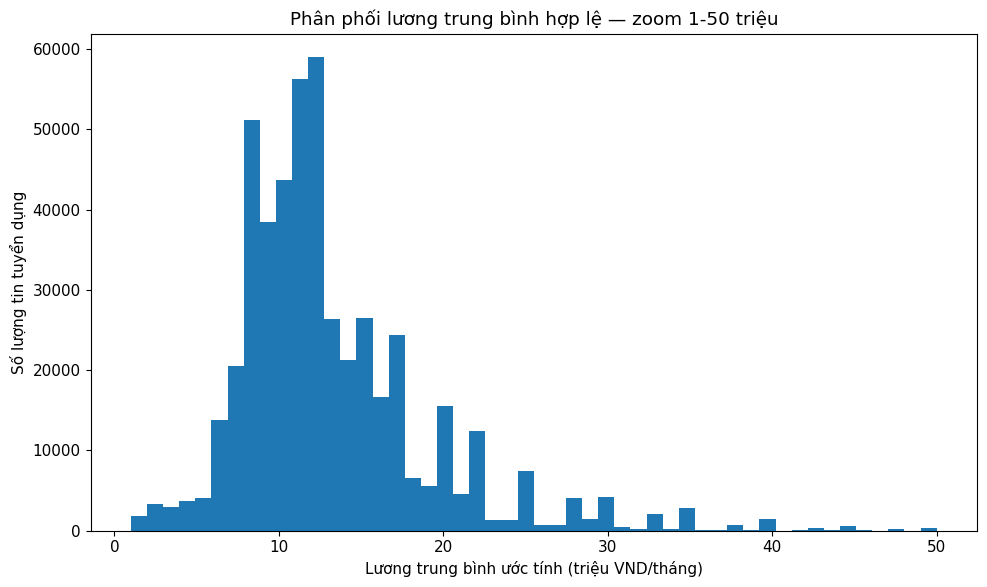

In [13]:
salary_valid = clean_train[
    (clean_train["salary_available"] == 1)
    & (clean_train["salary_parse_issue"] == 0)
    & (clean_train["salary_currency"] == "VND")
    & (clean_train["salary_min_million_vnd"].notna())
    & (clean_train["salary_max_million_vnd"].notna())
    & (clean_train["salary_avg_million_vnd"].notna())
    & (clean_train["salary_min_million_vnd"] >= 1)
    & (clean_train["salary_max_million_vnd"] <= 200)
    & (clean_train["salary_min_million_vnd"] <= clean_train["salary_max_million_vnd"])
    & (clean_train["salary_avg_million_vnd"] >= 1)
    & (clean_train["salary_avg_million_vnd"] <= 200)
].copy()

salary_valid_ratio = len(salary_valid) / len(clean_train)

salary_valid_describe = (
    salary_valid[
        [
            "salary_min_million_vnd",
            "salary_max_million_vnd",
            "salary_avg_million_vnd"
        ]
    ]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "column"})
)

save_table(salary_valid_describe, "stage_04_salary_valid_describe.csv")

print("Valid salary rows:", len(salary_valid))
print("Valid salary ratio:", salary_valid_ratio)
display(salary_valid_describe)

plot_hist(
    salary_valid["salary_avg_million_vnd"],
    title="Phân phối lương trung bình hợp lệ",
    xlabel="Lương trung bình ước tính (triệu VND/tháng)",
    ylabel="Số lượng tin tuyển dụng",
    filename="stage_04_salary_avg_distribution.png",
    bins=60
)

salary_valid_zoom = salary_valid[salary_valid["salary_avg_million_vnd"] <= 50].copy()

plot_hist(
    salary_valid_zoom["salary_avg_million_vnd"],
    title="Phân phối lương trung bình hợp lệ — zoom 1-50 triệu",
    xlabel="Lương trung bình ước tính (triệu VND/tháng)",
    ylabel="Số lượng tin tuyển dụng",
    filename="stage_04_salary_avg_distribution_zoom_1_50.png",
    bins=50
)

## 13. Salary theo ngành chính

Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_salary_by_top_primary_industries_boxplot.png


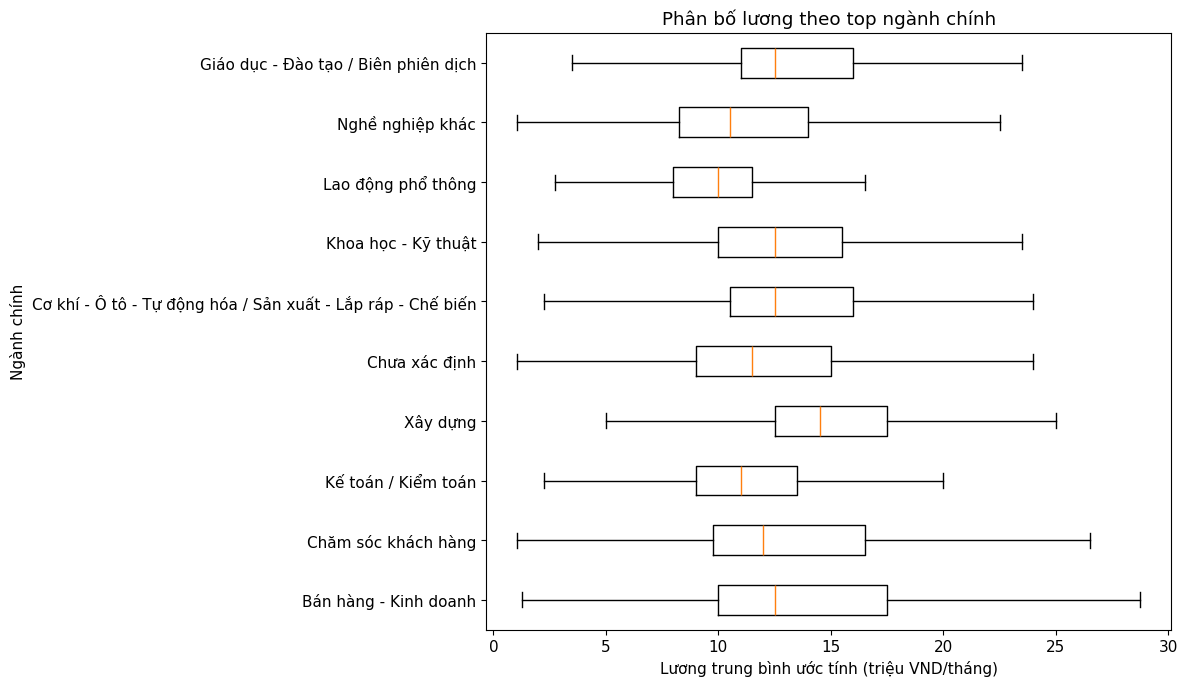

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_salary_by_primary_industry.csv


,primary_industry,count,mean,median,std,min,max
161,Y tế / Chăm sóc sức khỏe / Thẩm mỹ / Làm đẹp,1,55.000000,55.00,NaN,55.0,55.0
150,Vận chuyển / Giao nhận / Kho vận,1,35.000000,35.00,NaN,35.0,35.0
113,Quản lý điều hành,15,41.766667,26.50,36.155847,7.0,125.0
23,Công nghệ Thông tin,168,25.699405,25.00,17.114194,3.0,100.0
11,Bảo hiểm,3,21.666667,25.00,10.408330,10.0,30.0
145,UI/UX Designer,1,25.000000,25.00,NaN,25.0,25.0
52,IT phần mềm,806,26.718238,24.00,17.898572,1.5,180.0
116,Sinh viên làm thêm,1,24.000000,24.00,NaN,24.0,24.0
104,Pháp luật/ Pháp lý,12,21.833333,23.50,9.606658,6.0,32.5
91,Ngân hàng/ Tài Chính,53,24.211321,23.00,11.191062,1.2,60.0


Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_top_median_salary_by_primary_industry.csv


,primary_industry,count,mean,median,std,min,max
24,Công nghệ thông tin,1028,21.825875,17.5,13.591062,3.00,100.0
90,Ngân hàng / Tài chính - Đầu tư - Chứng Khoán,8427,16.931986,16.5,7.310813,1.25,115.0
14,Bất động sản,9227,21.674585,16.0,17.935311,1.05,132.5
111,Quản lý dự án,2752,18.536501,16.0,9.505679,1.50,112.5
159,Xây dựng,24697,15.387051,14.5,5.778872,1.50,149.5
74,Luật - Pháp Lý - Tuân thủ,4478,16.063455,14.5,7.389392,1.05,115.0
50,IT Phần mềm,4301,16.151279,13.5,10.066104,1.05,150.0
63,Kiến trúc - Thiết kế nội ngoại thất,4395,14.036030,13.0,4.784646,1.50,75.0
6,Bán hàng - Kinh doanh,48230,14.399389,12.5,7.842110,1.25,155.0
26,Cơ khí - Ô tô - Tự động hóa / Sản xuất - Lắp ráp - Chế biến,21996,14.139866,12.5,6.424759,1.05,152.5


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_top_median_salary_by_primary_industry.png


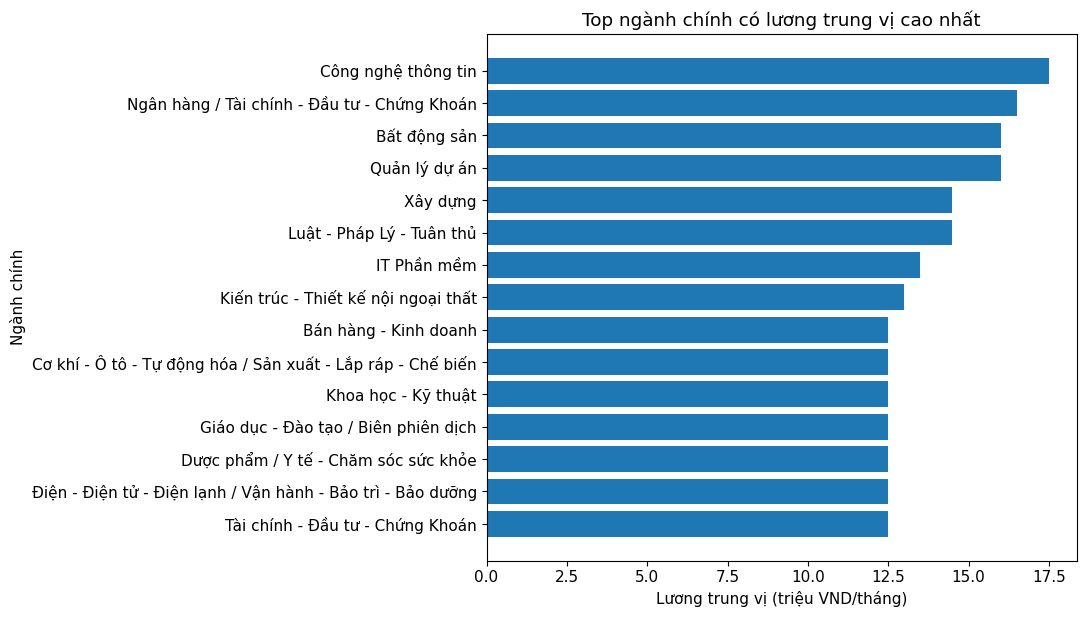

In [14]:
top_primary_industries = (
    clean_train["primary_industry"]
    .value_counts()
    .head(10)
    .index
)

salary_top_primary_industries = salary_valid[
    salary_valid["primary_industry"].isin(top_primary_industries)
].copy()

boxplot_data = [
    salary_top_primary_industries.loc[
        salary_top_primary_industries["primary_industry"] == industry,
        "salary_avg_million_vnd"
    ].dropna().values
    for industry in top_primary_industries
]

boxplot_labels = [shorten_label(industry, 70) for industry in top_primary_industries]

plt.figure(figsize=(12, 7))
plt.boxplot(boxplot_data, vert=False, labels=boxplot_labels, showfliers=False)
plt.title("Phân bố lương theo top ngành chính")
plt.xlabel("Lương trung bình ước tính (triệu VND/tháng)")
plt.ylabel("Ngành chính")
save_fig("stage_04_salary_by_top_primary_industries_boxplot.png")
plt.show()

salary_by_primary_industry = (
    salary_valid
    .groupby("primary_industry")["salary_avg_million_vnd"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
    .sort_values(["median", "count"], ascending=[False, False])
)

save_table(salary_by_primary_industry, "stage_04_salary_by_primary_industry.csv")
display(salary_by_primary_industry.head(20))

salary_by_primary_industry_filtered = salary_by_primary_industry[
    salary_by_primary_industry["count"] >= 1000
].copy()

top_median_salary_industries = (
    salary_by_primary_industry_filtered
    .sort_values("median", ascending=False)
    .head(15)
)

save_table(top_median_salary_industries, "stage_04_top_median_salary_by_primary_industry.csv")
display(top_median_salary_industries)

plot_horizontal_bar(
    data=top_median_salary_industries,
    label_col="primary_industry",
    value_col="median",
    title="Top ngành chính có lương trung vị cao nhất",
    xlabel="Lương trung vị (triệu VND/tháng)",
    ylabel="Ngành chính",
    filename="stage_04_top_median_salary_by_primary_industry.png",
    max_label_len=70
)

## 14. Salary theo tỉnh/thành

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_salary_by_location_city.csv


,location_city,count,mean,median,std,min,max
47,TP Hồ Chí Minh,258564,13.274385,11.5,7.278837,1.00,180.0
18,Hà Nội,126874,14.215824,12.5,8.211458,1.00,150.0
2,Bình Dương,23090,13.432776,12.0,6.175433,1.25,115.0
25,Khác/Không rõ,13153,13.307215,11.0,9.702512,1.25,152.5
62,Đồng Nai,9021,13.073196,12.0,5.685165,1.05,115.0
59,Đà Nẵng,7163,12.012571,10.5,7.574413,1.00,115.0
30,Long An,6600,12.920500,12.0,5.139148,1.50,65.0
9,Bắc Ninh,4248,14.957133,12.5,7.914761,1.50,200.0
21,Hưng Yên,4028,13.755313,12.0,6.502818,1.50,150.0
23,Hải Phòng,3959,14.276408,12.5,8.342073,1.20,104.0


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_salary_by_top_location_cities_boxplot.png


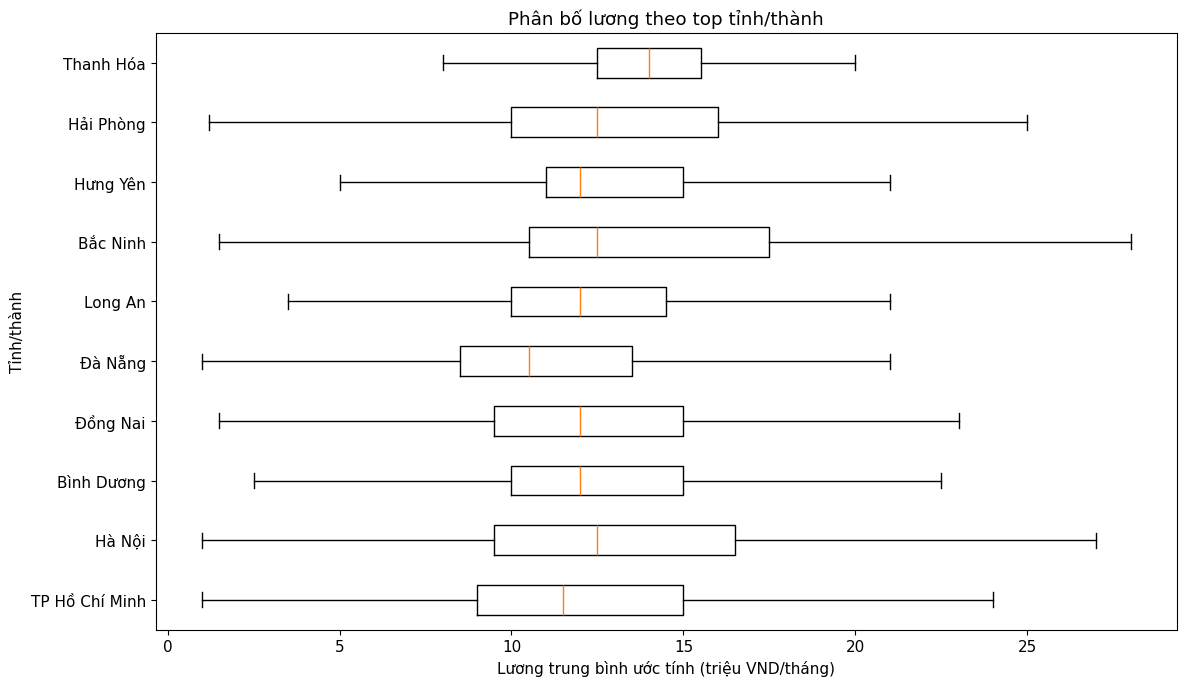

In [15]:
salary_by_location_city = (
    salary_valid
    .groupby("location_city")["salary_avg_million_vnd"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
    .sort_values(["count", "median"], ascending=[False, False])
)

save_table(salary_by_location_city, "stage_04_salary_by_location_city.csv")
display(salary_by_location_city.head(20))

top_salary_locations = (
    salary_valid[salary_valid["location_city"] != "Khác/Không rõ"]["location_city"]
    .value_counts()
    .head(10)
    .index
)

salary_top_locations = salary_valid[
    salary_valid["location_city"].isin(top_salary_locations)
]

boxplot_data = [
    salary_top_locations.loc[
        salary_top_locations["location_city"] == location,
        "salary_avg_million_vnd"
    ].dropna().values
    for location in top_salary_locations
]

plt.figure(figsize=(12, 7))
plt.boxplot(boxplot_data, vert=False, labels=list(top_salary_locations), showfliers=False)
plt.title("Phân bố lương theo top tỉnh/thành")
plt.xlabel("Lương trung bình ước tính (triệu VND/tháng)")
plt.ylabel("Tỉnh/thành")
save_fig("stage_04_salary_by_top_location_cities_boxplot.png")
plt.show()

## 15. Phân tích độ dài văn bản

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_text_length_summary.csv


,column,count,mean,std,min,25%,50%,75%,max
0,job_title_char_len,546190.0,35.885338,18.979456,0.0,21.0,32.0,46.0,255.0
1,job_title_word_count,546190.0,7.747851,4.151319,0.0,4.0,7.0,10.0,55.0
2,job_description_char_len,546190.0,599.173333,488.801716,0.0,301.0,476.0,741.0,29048.0
3,job_description_word_count,546190.0,129.682686,101.771957,0.0,66.0,104.0,161.0,4169.0
4,requirements_char_len,546190.0,323.102567,229.527878,0.0,172.0,281.0,418.0,6630.0
5,requirements_word_count,546190.0,69.436434,48.028785,0.0,38.0,61.0,90.0,1213.0
6,benefits_char_len,546190.0,376.606902,248.891065,0.0,216.0,323.0,468.0,32875.0
7,benefits_word_count,546190.0,80.769769,52.511591,0.0,46.0,69.0,100.0,1345.0


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_job_description_word_count_distribution.png


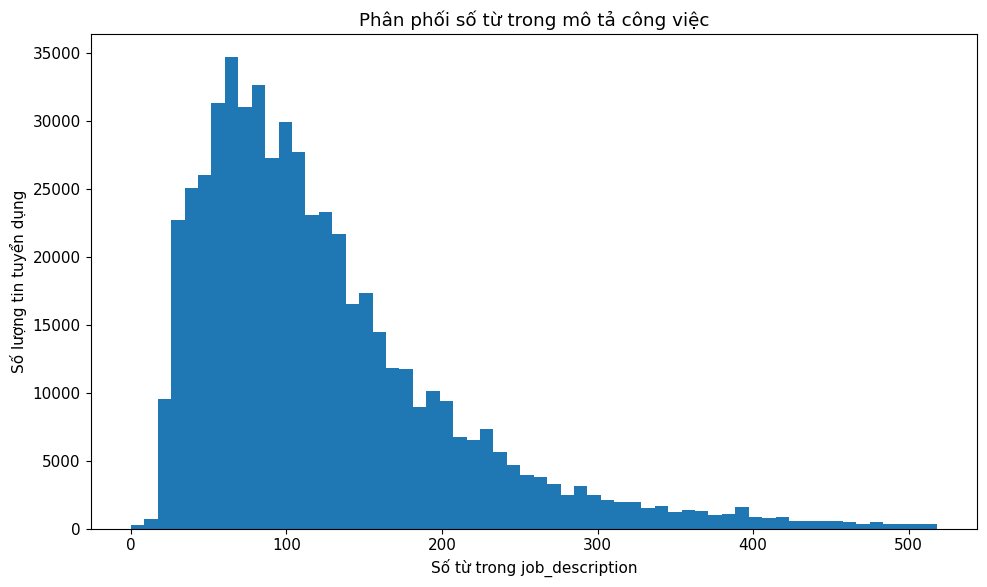

Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_requirements_word_count_distribution.png


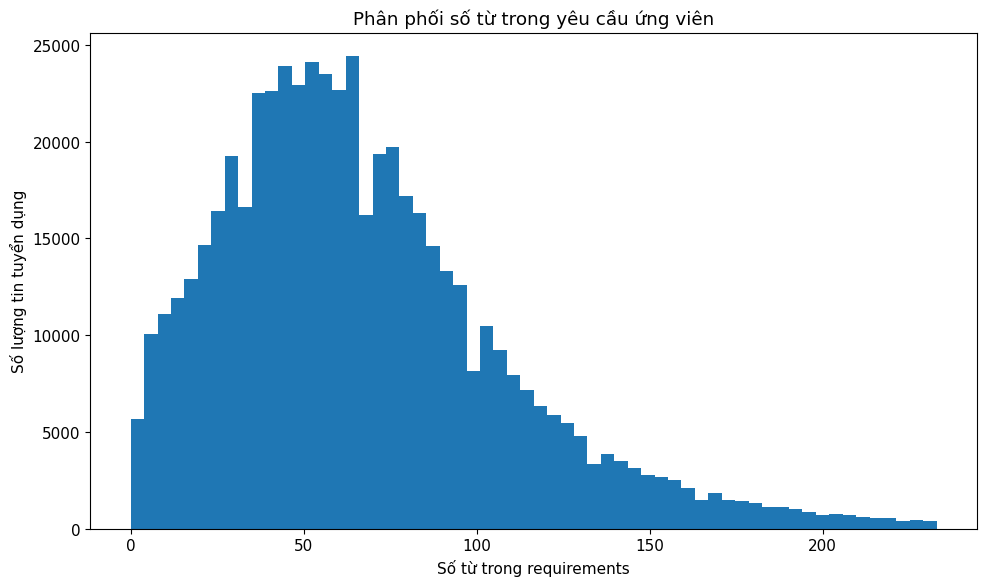

Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_benefits_word_count_distribution.png


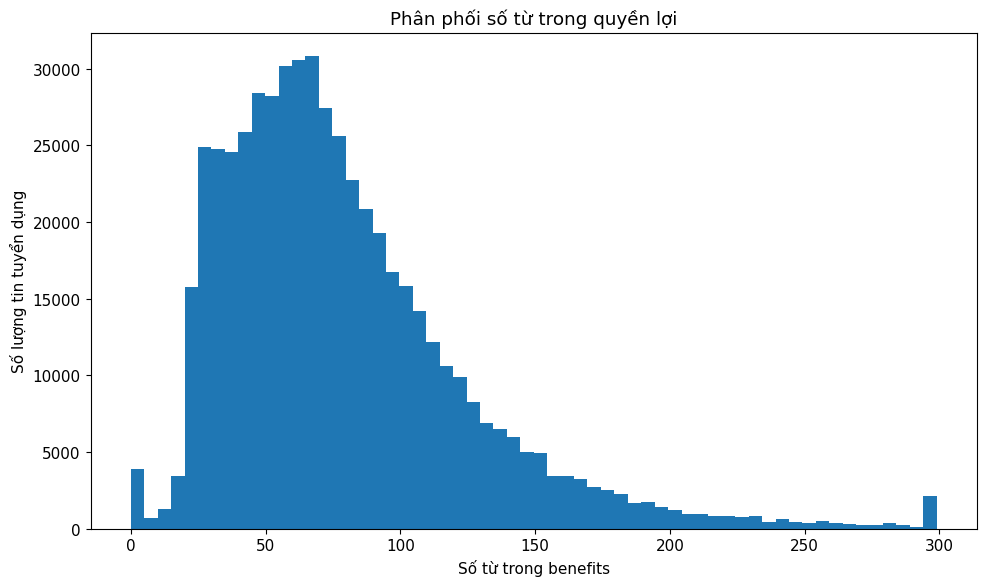

In [16]:
text_length_cols = [
    "job_title_char_len",
    "job_title_word_count",
    "job_description_char_len",
    "job_description_word_count",
    "requirements_char_len",
    "requirements_word_count",
    "benefits_char_len",
    "benefits_word_count",
]

text_length_summary = (
    clean_train[text_length_cols]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "column"})
)

save_table(text_length_summary, "stage_04_text_length_summary.csv")
display(text_length_summary)

plot_hist(
    clean_train["job_description_word_count"],
    title="Phân phối số từ trong mô tả công việc",
    xlabel="Số từ trong job_description",
    ylabel="Số lượng tin tuyển dụng",
    filename="stage_04_job_description_word_count_distribution.png",
    bins=60,
    cap_quantile=0.99
)

plot_hist(
    clean_train["requirements_word_count"],
    title="Phân phối số từ trong yêu cầu ứng viên",
    xlabel="Số từ trong requirements",
    ylabel="Số lượng tin tuyển dụng",
    filename="stage_04_requirements_word_count_distribution.png",
    bins=60,
    cap_quantile=0.99
)

plot_hist(
    clean_train["benefits_word_count"],
    title="Phân phối số từ trong quyền lợi",
    xlabel="Số từ trong benefits",
    ylabel="Số lượng tin tuyển dụng",
    filename="stage_04_benefits_word_count_distribution.png",
    bins=60,
    cap_quantile=0.99
)

## 16. Top keywords / n-grams

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_top_job_title_ngrams.csv


,term,count
0,kế toán,53259
1,tư vấn,33602
2,bán hàng,29688
3,đi ngay,25599
4,thu nhập,20964
5,khách hàng,18470
6,quản lý,17465
7,thiết kế,16294
8,hà nội,15998
9,tổng hợp,15895


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_top_job_title_ngrams.png


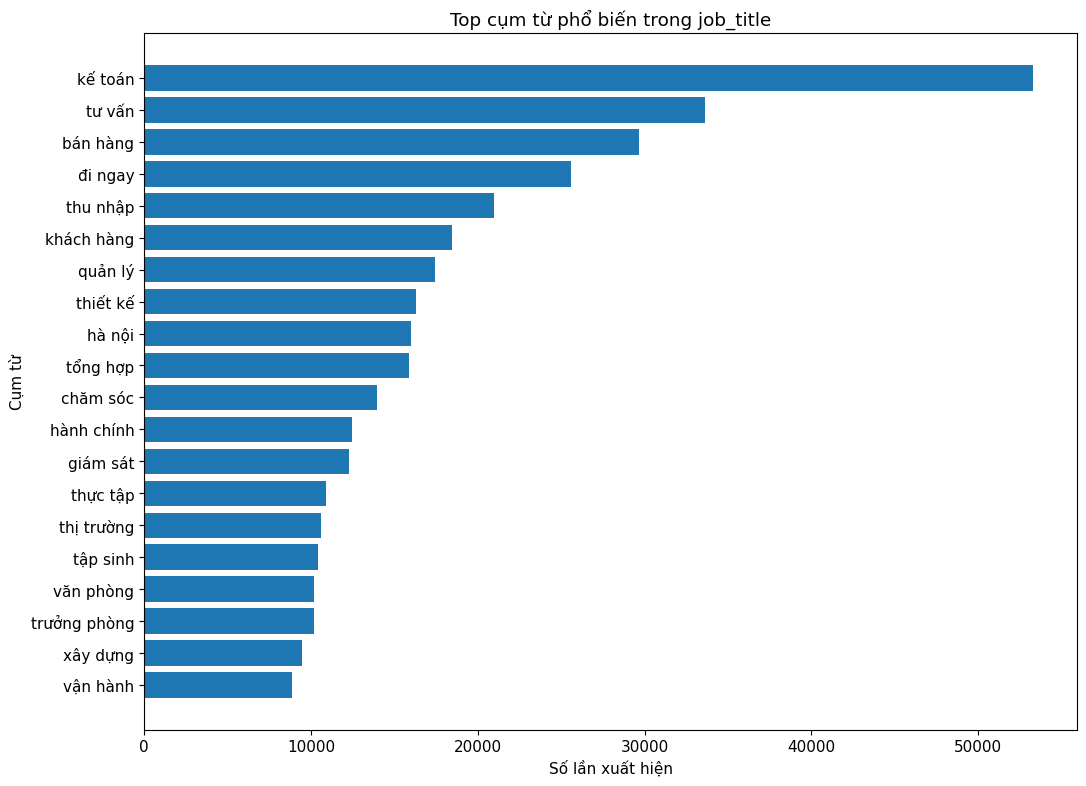

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_top_requirements_ngrams.csv


,term,count
0,giao tiếp,43884
1,đại học,27192
2,cao đẳng,25545
3,trách nhiệm,24999
4,văn phòng,22501
5,kế toán,21918
6,trung thực,21660
7,tinh thần,19944
8,vị trí,19678
9,quản lý,18483


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_top_requirements_ngrams.png


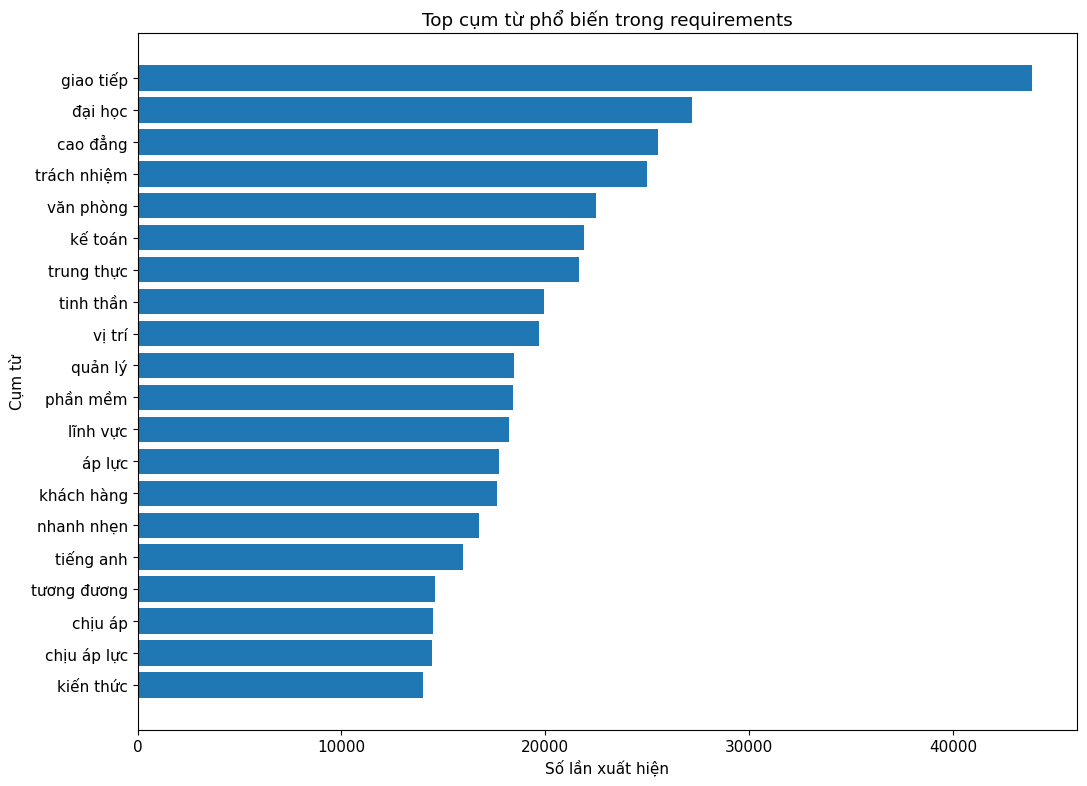

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_top_job_description_ngrams.csv


,term,count
0,khách hàng,154585
1,quản lý,72055
2,sản phẩm,58836
3,hỗ trợ,42862
4,kiểm tra,37047
5,tư vấn,35924
6,kế hoạch,35671
7,bán hàng,32118
8,xây dựng,30628
9,chăm sóc,25233


Saved figure: D:\DataScientFinalProject\outputs\figures\stage_04_top_job_description_ngrams.png


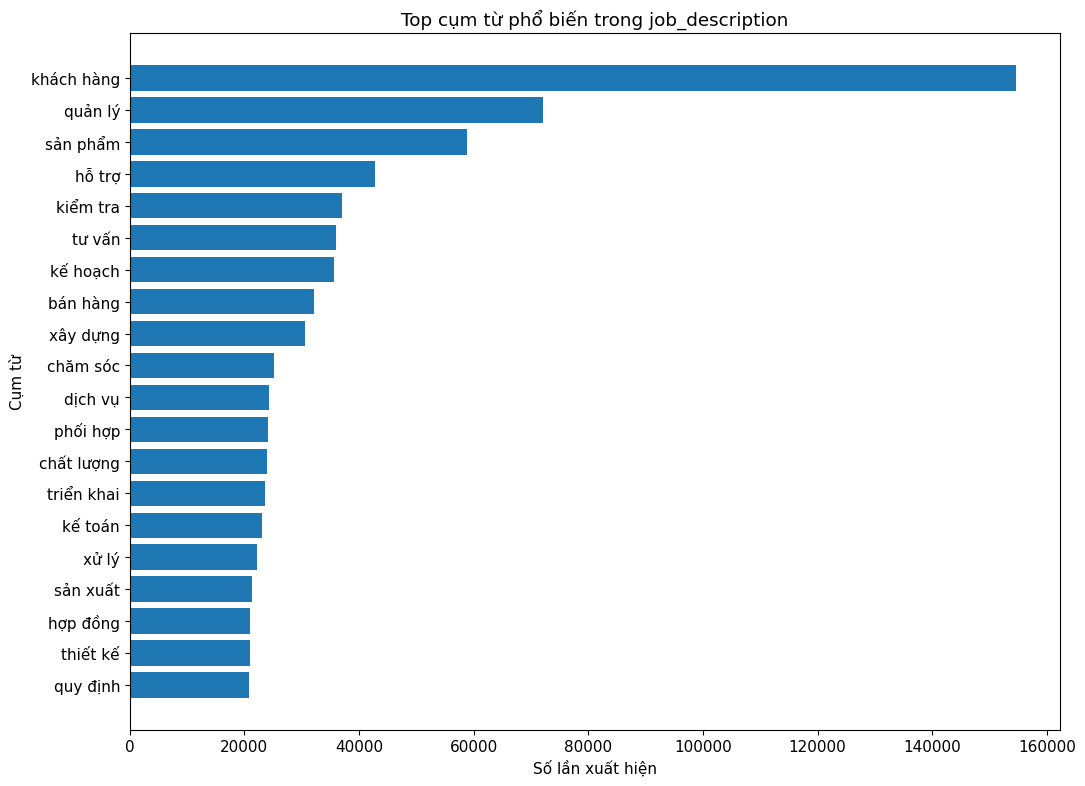

In [17]:
VIETNAMESE_STOPWORDS = [
    "và", "là", "của", "cho", "với", "các", "một", "những", "được",
    "trong", "tại", "theo", "về", "khi", "từ", "đến", "hoặc", "này",
    "có", "không", "trên", "dưới", "sẽ", "đã", "đang", "cần", "tuyển",
    "nhân", "viên", "chuyên", "công", "việc", "làm", "tốt", "kỹ", "năng",
    "kinh", "nghiệm", "ứng", "viên", "yêu", "cầu", "ưu", "tiên", "biết",
    "khả", "năng", "thành", "thạo", "liên", "quan", "trình", "độ",
    "năm", "tháng", "ngày", "mô", "tả", "quyền", "lợi", "phúc", "lợi",
    "mức", "lương", "thời", "gian", "địa", "điểm"
]

BAD_NGRAM_TERMS = [
    "sóc khách", "toán tổng", "nghiệp cao", "nghiệp cao đẳng",
    "trở lên", "sử dụng", "thực hiện", "đảm bảo", "báo cáo",
    "hoạt động", "thông tin", "bộ phận", "hồ sơ", "phát triển", "hệ thống"
]


def filter_bad_ngrams(ngram_df):
    result = ngram_df.copy()

    if len(BAD_NGRAM_TERMS) == 0:
        return result

    bad_pattern = "|".join([re.escape(term) for term in BAD_NGRAM_TERMS])

    result = result[
        ~result["term"].str.contains(bad_pattern, regex=True, na=False)
    ].copy()

    return result.reset_index(drop=True)


def get_top_ngrams(
    text_series,
    ngram_range=(2, 3),
    top_n=30,
    min_df=20,
    max_df=0.8,
    sample_size=None,
    apply_filter=True,
):
    texts = text_series.fillna("").astype(str)

    if sample_size is not None and len(texts) > sample_size:
        texts = texts.sample(n=sample_size, random_state=42)

    vectorizer = CountVectorizer(
        stop_words=VIETNAMESE_STOPWORDS,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        token_pattern=r"(?u)\b\w\w+\b"
    )

    X = vectorizer.fit_transform(texts)

    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())

    sorted_idx = counts.argsort()[::-1]

    result = pd.DataFrame({
        "term": terms[sorted_idx],
        "count": counts[sorted_idx]
    })

    if apply_filter:
        result = filter_bad_ngrams(result)

    return result.head(top_n).reset_index(drop=True)


def plot_top_terms(terms_df, title, filename):
    plot_data = terms_df.head(20).iloc[::-1]

    plt.figure(figsize=(11, 8))
    plt.barh(plot_data["term"], plot_data["count"])
    plt.title(title)
    plt.xlabel("Số lần xuất hiện")
    plt.ylabel("Cụm từ")
    save_fig(filename)
    plt.show()


top_job_title_ngrams = get_top_ngrams(
    clean_train["job_title"],
    ngram_range=(2, 2),
    top_n=30,
    min_df=10,
    sample_size=None,
    apply_filter=True
)
save_table(top_job_title_ngrams, "stage_04_top_job_title_ngrams.csv")
display(top_job_title_ngrams)
plot_top_terms(
    top_job_title_ngrams,
    title="Top cụm từ phổ biến trong job_title",
    filename="stage_04_top_job_title_ngrams.png"
)

top_requirements_ngrams = get_top_ngrams(
    clean_train["requirements"],
    ngram_range=(2, 3),
    top_n=30,
    min_df=20,
    sample_size=100000,
    apply_filter=True
)
save_table(top_requirements_ngrams, "stage_04_top_requirements_ngrams.csv")
display(top_requirements_ngrams)
plot_top_terms(
    top_requirements_ngrams,
    title="Top cụm từ phổ biến trong requirements",
    filename="stage_04_top_requirements_ngrams.png"
)

top_description_ngrams = get_top_ngrams(
    clean_train["job_description"],
    ngram_range=(2, 3),
    top_n=30,
    min_df=20,
    sample_size=100000,
    apply_filter=True
)
save_table(top_description_ngrams, "stage_04_top_job_description_ngrams.csv")
display(top_description_ngrams)
plot_top_terms(
    top_description_ngrams,
    title="Top cụm từ phổ biến trong job_description",
    filename="stage_04_top_job_description_ngrams.png"
)

## 17. So sánh phân bố train/test

In [18]:
primary_industry_train_test_compare = compare_train_test_distribution(
    clean_train, clean_test, column="primary_industry"
)

location_city_train_test_compare = compare_train_test_distribution(
    clean_train, clean_test, column="location_city"
)

year_train_test_compare = compare_train_test_distribution(
    clean_train, clean_test, column="year"
)

save_table(primary_industry_train_test_compare, "stage_04_train_test_primary_industry_compare.csv")
save_table(location_city_train_test_compare, "stage_04_train_test_location_city_compare.csv")
save_table(year_train_test_compare, "stage_04_train_test_year_compare.csv")

display(primary_industry_train_test_compare.head(15))
display(location_city_train_test_compare.head(15))
display(year_train_test_compare.head(15))

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_train_test_primary_industry_compare.csv
Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_train_test_location_city_compare.csv
Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_train_test_year_compare.csv


,primary_industry,train_ratio,test_ratio,abs_diff
0,Bán hàng - Kinh doanh,0.096994,0.098125,0.001131
1,Chăm sóc khách hàng,0.092515,0.091484,0.001031
2,Kế toán / Kiểm toán,0.083248,0.083212,0.000035
3,Xây dựng,0.049470,0.048510,0.000960
4,Chưa xác định,0.042214,0.042529,0.000315
5,Cơ khí - Ô tô - Tự động hóa / Sản xuất - Lắp ráp - Chế biến,0.040958,0.041030,0.000071
6,Khoa học - Kỹ thuật,0.039538,0.039645,0.000108
7,Lao động phổ thông,0.038573,0.038129,0.000443
8,Nghề nghiệp khác,0.038421,0.038640,0.000220
9,Giáo dục - Đào tạo / Biên phiên dịch,0.030462,0.031225,0.000763


,location_city,train_ratio,test_ratio,abs_diff
0,TP Hồ Chí Minh,0.522496,0.525491,0.002995
1,Hà Nội,0.258156,0.257679,0.000477
2,Bình Dương,0.046445,0.047258,0.000813
3,Khác/Không rõ,0.024634,0.023777,0.000857
4,Đồng Nai,0.018583,0.018125,0.000458
5,Đà Nẵng,0.015154,0.014154,0.001000
6,Long An,0.013087,0.013001,0.000086
7,Bắc Ninh,0.008830,0.008486,0.000344
8,Hải Phòng,0.008316,0.008321,0.000005
9,Hưng Yên,0.008149,0.007431,0.000718


,year,train_ratio,test_ratio,abs_diff
0,2025,0.264337,0.263775,0.000561
1,2024,0.261786,0.264698,0.002912
2,2023,0.213774,0.212777,0.000997
3,2022,0.183184,0.180925,0.002258
4,2026,0.076920,0.077824,0.000904


## 18. Tổng hợp insight chính

In [19]:
n_display_columns_added = 2

eda_summary = {
    "n_train_rows": len(clean_train),
    "n_test_rows": len(clean_test),
    "n_clean_input_columns": clean_train.shape[1] - n_display_columns_added,
    "n_eda_columns_after_display": clean_train.shape[1],

    "top_primary_industry": primary_industry_counts.iloc[0]["primary_industry"],
    "top_primary_industry_count": int(primary_industry_counts.iloc[0]["count"]),
    "top_primary_industry_ratio_percent": float(primary_industry_counts.iloc[0]["ratio_percent"]),

    "top_location_city": location_city_counts.iloc[0]["location_city"],
    "top_location_city_count": int(location_city_counts.iloc[0]["count"]),
    "top_location_city_ratio_percent": float(location_city_counts.iloc[0]["ratio_percent"]),

    "location_city_unknown_ratio_percent": float(location_unknown_counts.loc[
        location_unknown_counts["location_status"] == "Khác/Không rõ",
        "ratio_percent"
    ].iloc[0]) if (location_unknown_counts["location_status"] == "Khác/Không rõ").any() else 0.0,

    "top_job_type": job_type_counts.iloc[0]["job_type"],
    "top_job_type_count": int(job_type_counts.iloc[0]["count"]),
    "top_job_type_ratio_percent": float(job_type_counts.iloc[0]["ratio_percent"]),

    "salary_valid_rows": len(salary_valid),
    "salary_valid_ratio_percent": float(salary_valid_ratio * 100),
    "salary_avg_median_million_vnd": float(salary_valid["salary_avg_million_vnd"].median()),
    "salary_avg_mean_million_vnd": float(salary_valid["salary_avg_million_vnd"].mean()),

    "job_description_word_count_median": float(clean_train["job_description_word_count"].median()),
    "requirements_word_count_median": float(clean_train["requirements_word_count"].median()),
}

eda_summary_df = pd.DataFrame([eda_summary])
save_table(eda_summary_df, "stage_04_eda_summary.csv")
display(eda_summary_df)

summary_lines = [
    "# Stage 04 EDA Summary Optimized",
    "",
    "## Dataset overview",
    "",
    f"- Train rows: {len(clean_train):,}",
    f"- Test rows: {len(clean_test):,}",
    f"- Clean input columns: {clean_train.shape[1] - n_display_columns_added}",
    f"- EDA columns after display features: {clean_train.shape[1]}",
    "",
    "## Key categorical insights",
    "",
    f"- Top primary industry: {eda_summary['top_primary_industry']} ({eda_summary['top_primary_industry_ratio_percent']:.2f}%)",
    f"- Top location city: {eda_summary['top_location_city']} ({eda_summary['top_location_city_ratio_percent']:.2f}%)",
    f"- Unknown location city ratio: {eda_summary['location_city_unknown_ratio_percent']:.2f}%",
    f"- Top job type: {eda_summary['top_job_type']} ({eda_summary['top_job_type_ratio_percent']:.2f}%)",
    "",
    "## Salary insights",
    "",
    "- Salary valid filter: VND, no issue, salary_avg_million_vnd from 1 to 200.",
    f"- Valid salary rows: {len(salary_valid):,}",
    f"- Valid salary ratio: {salary_valid_ratio * 100:.2f}%",
    f"- Median salary_avg_million_vnd: {salary_valid['salary_avg_million_vnd'].median():.2f}",
    f"- Mean salary_avg_million_vnd: {salary_valid['salary_avg_million_vnd'].mean():.2f}",
    "",
    "## Text length insights",
    "",
    f"- Median job_description word count: {clean_train['job_description_word_count'].median():.2f}",
    f"- Median requirements word count: {clean_train['requirements_word_count'].median():.2f}",
    "",
    "## Optimizations applied",
    "",
    "- Standardized display labels for job_position and education_level.",
    "- Added salary zoom distribution for 1-50 million VND/month.",
    "- Excluded 'Khác/Không rõ' from salary-by-location boxplot.",
    "- Added median salary by primary_industry chart.",
    "- Filtered broken or overly generic n-grams.",
    "",
    "## Implication for clustering",
    "",
    "- Text columns contain important semantic information, so TF-IDF should be used in feature engineering.",
    "- primary_industry, location_city, job_type, experience_level, education_level, and salary features can help interpret clusters.",
    "- Salary should be used with control rules because it contains unavailable and abnormal values.",
]

summary_md = "\n".join(summary_lines)

summary_path = EDA_DIR / "stage_04_eda_summary_optimized.md"
summary_path.write_text(summary_md, encoding="utf-8")

print("Saved EDA markdown summary:", summary_path)
print(summary_md)

Saved table: D:\DataScientFinalProject\outputs\tables\stage_04_eda_summary.csv


,n_train_rows,n_test_rows,n_clean_input_columns,n_eda_columns_after_display,top_primary_industry,top_primary_industry_count,top_primary_industry_ratio_percent,top_location_city,top_location_city_count,top_location_city_ratio_percent,location_city_unknown_ratio_percent,top_job_type,top_job_type_count,top_job_type_ratio_percent,salary_valid_rows,salary_valid_ratio_percent,salary_avg_median_million_vnd,salary_avg_mean_million_vnd,job_description_word_count_median,requirements_word_count_median
0,546190,60688,31,33,Bán hàng - Kinh doanh,52977,9.699372,TP Hồ Chí Minh,285382,52.249583,2.463428,Toàn thời gian,503335,92.153829,492340,90.140793,12.0,13.52726,104.0,61.0


Saved EDA markdown summary: D:\DataScientFinalProject\outputs\eda_stage_04\stage_04_eda_summary_optimized.md
# Stage 04 EDA Summary Optimized

## Dataset overview

- Train rows: 546,190
- Test rows: 60,688
- Clean input columns: 31
- EDA columns after display features: 33

## Key categorical insights

- Top primary industry: Bán hàng - Kinh doanh (9.70%)
- Top location city: TP Hồ Chí Minh (52.25%)
- Unknown location city ratio: 2.46%
- Top job type: Toàn thời gian (92.15%)

## Salary insights

- Salary valid filter: VND, no issue, salary_avg_million_vnd from 1 to 200.
- Valid salary rows: 492,340
- Valid salary ratio: 90.14%
- Median salary_avg_million_vnd: 12.00
- Mean salary_avg_million_vnd: 13.53

## Text length insights

- Median job_description word count: 104.00
- Median requirements word count: 61.00

## Optimizations applied

- Standardized display labels for job_position and education_level.
- Added salary zoom distribution for 1-50 million VND/month.
- Excluded 'Khác/Không r

## 19. Manifest output

In [20]:
figure_files = sorted([p.name for p in FIGURE_DIR.glob("stage_04_*.png")])
table_files = sorted([p.name for p in TABLE_DIR.glob("stage_04_*.csv")])
eda_files = sorted([p.name for p in EDA_DIR.glob("stage_04_*")])

manifest_rows = []

for file in figure_files:
    manifest_rows.append({"type": "figure", "filename": file, "path": str(FIGURE_DIR / file)})

for file in table_files:
    manifest_rows.append({"type": "table", "filename": file, "path": str(TABLE_DIR / file)})

for file in eda_files:
    manifest_rows.append({"type": "eda_summary", "filename": file, "path": str(EDA_DIR / file)})

manifest_df = pd.DataFrame(manifest_rows)

manifest_df.to_csv(TABLE_DIR / "stage_04_output_manifest.csv", index=False, encoding="utf-8-sig")

display(manifest_df)

,type,filename,path
0,figure,stage_04_benefits_word_count_distribution.png,D:\DataScientFinalProject\outputs\figures\stage_04_benefits_word_count_distribution.png
1,figure,stage_04_education_level_distribution.png,D:\DataScientFinalProject\outputs\figures\stage_04_education_level_distribution.png
2,figure,stage_04_experience_level_distribution.png,D:\DataScientFinalProject\outputs\figures\stage_04_experience_level_distribution.png
3,figure,stage_04_job_description_word_count_distribution.png,D:\DataScientFinalProject\outputs\figures\stage_04_job_description_word_count_distribution.png
4,figure,stage_04_job_position_distribution.png,D:\DataScientFinalProject\outputs\figures\stage_04_job_position_distribution.png
5,figure,stage_04_job_type_distribution.png,D:\DataScientFinalProject\outputs\figures\stage_04_job_type_distribution.png
6,figure,stage_04_location_city_unknown_distribution.png,D:\DataScientFinalProject\outputs\figures\stage_04_location_city_unknown_distribution.png
7,figure,stage_04_requirements_word_count_distribution.png,D:\DataScientFinalProject\outputs\figures\stage_04_requirements_word_count_distribution.png
8,figure,stage_04_salary_avg_distribution.png,D:\DataScientFinalProject\outputs\figures\stage_04_salary_avg_distribution.png
9,figure,stage_04_salary_avg_distribution_zoom_1_50.png,D:\DataScientFinalProject\outputs\figures\stage_04_salary_avg_distribution_zoom_1_50.png


# Kết luận Giai đoạn 4

Sau khi chạy xong notebook, các output tối ưu cần có:

```text
stage_04_salary_avg_distribution_zoom_1_50.png
stage_04_top_median_salary_by_primary_industry.png
stage_04_top_primary_industries.png
stage_04_top_location_cities.png
stage_04_salary_by_top_primary_industries_boxplot.png
stage_04_salary_by_top_location_cities_boxplot.png
stage_04_top_job_title_ngrams.png
stage_04_top_requirements_ngrams.png
stage_04_top_job_description_ngrams.png
stage_04_eda_summary.csv
stage_04_eda_summary_optimized.md
stage_04_output_manifest.csv
```

Giai đoạn 4 giúp hiểu dữ liệu trước khi phân cụm. Các insight chính sẽ được dùng để giải thích vì sao giai đoạn feature engineering cần kết hợp:

```text
- Text features: job_title, job_description, requirements, benefits
- Categorical features: primary_industry, location_city, job_type, experience_level, education_level, job_position
- Numeric features: salary, text length, year
```